# 02. Tokenization

**Tier:** Foundations
**Estimated time:** 40 minutes
**Prerequisites:** 00, 01
**Priority:** 🟡 Important — token-level thinking is unavoidable when reasoning about context budgets, costs, and model limits. *If skipped, revisit when:* before notebook 13 if context-window costs feel abstract.
**Source material:** @sairahul1 — "20 AI Concepts You Must Understand in 2026"; @theahmadosman build-first roadmap (tokenizer first)

## What You'll Learn
- Why LLMs read **tokens**, not characters or words
- How **Byte-Pair Encoding (BPE)** builds a vocabulary by merging frequent pairs — implemented from scratch
- How a real tokenizer (GPT-2) splits text, and why "tokens ≠ words" explains things like the famous "how many r's in strawberry" failure

## Why This Matters
A model never sees your text — it sees a list of integers. Token count drives your API bill, your context-window limits, and even which reasoning the model finds easy or hard. Tokenization is the first and most under-appreciated step in the whole pipeline.

In [ ]:
import os

# Load .env if python-dotenv is installed; harmless if it isn't.
# Not required for this notebook (runs fully offline with NumPy/transformers).
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

## Why not just use words or characters?

- **Characters** give a tiny vocabulary (~256 bytes) but make sequences very long, so the model wastes capacity learning to spell.
- **Words** keep sequences short but the vocabulary explodes (millions of words, plus every typo and rare name becomes an unknown token).

**Subword tokenization** is the compromise everyone uses. Common words become a single token; rare words break into reusable pieces. "tokenization" might become `token` + `ization`. This keeps the vocabulary at a manageable ~50k–100k while still representing any string.

**Byte-Pair Encoding (BPE)** is the most common recipe. The idea is delightfully simple: start with individual characters, then repeatedly find the most frequent adjacent pair and merge it into a new symbol. Do that a few thousand times and the frequent merges *are* your subwords.

## BPE from scratch

We'll train BPE on a tiny corpus so you can watch every merge happen. The classic trick: represent each word as a sequence of characters with a special end-of-word marker `</w>`, then merge the most frequent adjacent pair across the whole corpus.

In [1]:
from collections import Counter

corpus = "the cat sat on the mat the cat ran the dog sat the dog ran".split()

def get_vocab(words):
    # Represent each word as space-separated chars + an end-of-word marker.
    vocab = Counter()
    for w in words:
        vocab[" ".join(list(w)) + " </w>"] += 1
    return vocab

vocab = get_vocab(corpus)
for token_seq, count in vocab.items():
    print(f"{count} x  {token_seq}")

5 x  t h e </w>
2 x  c a t </w>
2 x  s a t </w>
1 x  o n </w>
1 x  m a t </w>
2 x  r a n </w>
2 x  d o g </w>


In [2]:
def count_pairs(vocab):
    """Count every adjacent symbol pair across the whole corpus, weighted by word frequency."""
    pairs = Counter()
    for token_seq, freq in vocab.items():
        symbols = token_seq.split()
        for a, b in zip(symbols, symbols[1:]):
            pairs[(a, b)] += freq
    return pairs

def merge_pair(pair, vocab):
    """Merge every occurrence of `pair` into a single combined symbol."""
    a, b = pair
    bigram = a + " " + b
    merged = a + b
    return {seq.replace(bigram, merged): freq for seq, freq in vocab.items()}

# Run BPE for a handful of merges, printing the winning pair each round.
merges = []
for step in range(8):
    pairs = count_pairs(vocab)
    if not pairs:
        break
    best = pairs.most_common(1)[0][0]
    merges.append(best)
    vocab = merge_pair(best, vocab)
    print(f"merge {step+1}: {best[0]!r} + {best[1]!r}  ->  {best[0]+best[1]!r}")

merge 1: 't' + 'h'  ->  'th'
merge 2: 'th' + 'e'  ->  'the'
merge 3: 'the' + '</w>'  ->  'the</w>'
merge 4: 'a' + 't'  ->  'at'
merge 5: 'at' + '</w>'  ->  'at</w>'
merge 6: 'n' + '</w>'  ->  'n</w>'
merge 7: 'c' + 'at</w>'  ->  'cat</w>'
merge 8: 's' + 'at</w>'  ->  'sat</w>'


In [3]:
# After training, the learned merges define how new text is tokenized.
print("Learned merges (in order):")
for a, b in merges:
    print(f"  {a!r} + {b!r}")
print("\nFinal vocab entries:")
for seq in vocab:
    print(" ", seq)

Learned merges (in order):
  't' + 'h'
  'th' + 'e'
  'the' + '</w>'
  'a' + 't'
  'at' + '</w>'
  'n' + '</w>'
  'c' + 'at</w>'
  's' + 'at</w>'

Final vocab entries:
  the</w>
  cat</w>
  sat</w>
  o n</w>
  m at</w>
  r a n</w>
  d o g </w>


*Watch how `t`+`h` → `th`, then `th`+`e` → `the`: BPE discovered the most common word in the corpus by merging from the bottom up. No linguistics required — just frequency.*

## A real tokenizer: GPT-2

Production tokenizers run the same algorithm at scale (GPT-2's vocabulary is ~50,257 tokens, learned over a huge web corpus, operating on raw **bytes** so it can encode any Unicode). Let's load it and see how it splits real text. The download is just the small vocab/merges files, not the model weights.

In [4]:
try:
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained("gpt2")
    HAS_TOK = True
    print("Loaded GPT-2 tokenizer. Vocabulary size:", tok.vocab_size)
except Exception as e:
    HAS_TOK = False
    print("Could not load GPT-2 tokenizer (offline?). Skipping live cells.")
    print(repr(e)[:200])

Loaded GPT-2 tokenizer. Vocabulary size: 50257


In [7]:
if HAS_TOK:
    examples = [
        "Tokenization is the first step.",
        "antidisestablishmentarianism",
        "strawberry",
        "GPT-4o costs $0.005 per 1K tokens.",
        "    leading spaces and\ttabs",
    ]
    for text in examples:
        ids = tok.encode(text)
        pieces = [ tok.decode([i]) for i in ids]   # decode each id back to its text piece
        print(f"\n{text!r}")
        print(f"  {len(ids)} tokens: {pieces}")


'Tokenization is the first step.'
  7 tokens: ['Token', 'ization', ' is', ' the', ' first', ' step', '.']

'antidisestablishmentarianism'
  5 tokens: ['ant', 'idis', 'establishment', 'arian', 'ism']

'strawberry'
  3 tokens: ['st', 'raw', 'berry']

'GPT-4o costs $0.005 per 1K tokens.'
  15 tokens: ['G', 'PT', '-', '4', 'o', ' costs', ' $', '0', '.', '005', ' per', ' 1', 'K', ' tokens', '.']

'    leading spaces and\ttabs'
  9 tokens: [' ', ' ', ' ', ' leading', ' spaces', ' and', '\t', 'tab', 's']


Notice three things:
- A leading **space** is part of the token (`" the"` differs from `"the"`). This is why prompt formatting matters.
- A rare word like *antidisestablishmentarianism* shatters into many subword pieces.
- **"strawberry"** splits into three tokens: `['st', 'raw', 'berry']`. The model literally cannot "see" the individual letters as distinct units — which is exactly why early LLMs miscounted the r's. Counting characters is a token-level blind spot, not a reasoning failure.

/var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/ipykernel_87974/432040721.py:24: UserWarning: Glyph 20320 (\N{CJK UNIFIED IDEOGRAPH-4F60}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/ipykernel_87974/432040721.py:24: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/ipykernel_87974/432040721.py:24: UserWarning: Glyph 19990 (\N{CJK UNIFIED IDEOGRAPH-4E16}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/ipykernel_87974/432040721.py:24: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/ipykernel_87974/432040721.py:24: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.

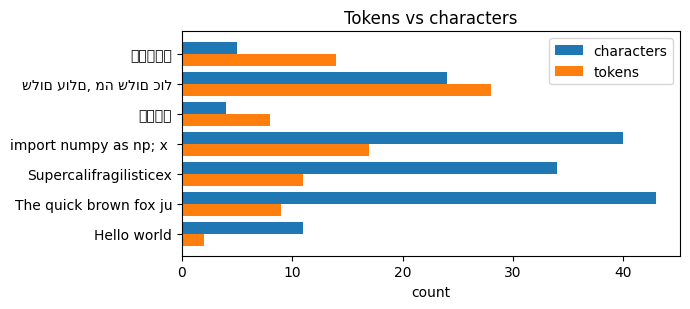

In [10]:
if HAS_TOK:
    %matplotlib inline
    import matplotlib.pyplot as plt

    sentences = [
        "Hello world",
        "The quick brown fox jumps over the lazy dog",
        "Supercalifragilisticexpialidocious",
        "import numpy as np; x = np.zeros((3, 3))",
        "你好世界",  # non-Latin scripts often use more tokens per character
        "שלום עולם, מה שלום כולם?",
        "안녕하세요"
        ""
    ]
    char_counts = [len(s) for s in sentences]
    token_counts = [len(tok.encode(s)) for s in sentences]

    y = range(len(sentences))
    plt.figure(figsize=(7, 3.2))
    plt.barh([i + 0.2 for i in y], char_counts, height=0.4, label="characters")
    plt.barh([i - 0.2 for i in y], token_counts, height=0.4, label="tokens")
    plt.yticks(list(y), [s[:22] for s in sentences])
    plt.xlabel("count"); plt.title("Tokens vs characters"); plt.legend()
    plt.tight_layout(); plt.show()

*Token-to-character ratio varies wildly by content: English prose is ~0.25 tokens/char, code and non-Latin scripts are much denser. This directly affects cost and context limits.*

---
**Note on token counts and real API costs.** GPT-2 is a *teaching* tokenizer — its vocabulary was learned in 2019, so its token counts won't exactly match what modern APIs charge. For accurate cost and context-window math, use the target model's own tokenizer:
- **OpenAI (GPT-4o, o3):** `tiktoken.get_encoding("o200k_base")`
- **Claude:** use the [token-counting endpoint](https://docs.anthropic.com/en/api/messages-count-tokens) or the `anthropic` SDK's `client.messages.count_tokens()`

The concepts — subwords, BPE, tokens ≠ words — are identical across all of them. GPT-2 is the right tool for *understanding*; swap it for the real tokenizer when you need *precision*.

## Exercises

In [ ]:
# Exercise 1 (Warm-up): More merges
# Task: Re-run the from-scratch BPE loop with 15 merges instead of 8 on a longer corpus
#       of your choice. What full words emerge as single tokens?
# Hint: Just paste more text into `corpus` and bump the range in the merge loop.

# YOUR CODE HERE


In [8]:
# Exercise 2 (Apply): A tokenizer.encode() function
# Task: Using your learned `merges` list, write encode(word) that applies the merges
#       in order to a NEW word and returns its final subword pieces.
# Hint: Start from list(word)+['</w>']; for each merge in order, scan and join that pair.

# YOUR CODE HERE

In [9]:
# Exercise 3 (Extend): Cost estimation
# Task: Given a price of $3 per million input tokens, estimate the cost of sending the
#       text of a 5,000-word document. Use the GPT-2 tokenizer to get a realistic token count.
# Hint: ~1.3 tokens per English word is a decent rule of thumb — verify it with tok.encode.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 2
def encode(word, merges):
    symbols = list(word) + ["</w>"]
    for a, b in merges:                       # apply merges in the order they were learned
        i = 0
        while i < len(symbols) - 1:
            if symbols[i] == a and symbols[i+1] == b:
                symbols[i:i+2] = [a + b]
            else:
                i += 1
    return symbols
print(encode("cats", merges))

# Exercise 3
words = 5000
text = "word " * words
n_tokens = len(tok.encode(text))
print(n_tokens, "tokens ->", f"${n_tokens/1e6 * 3:.4f}")
print("tokens per word:", n_tokens / words)
```
</details>

## Key Takeaways
- Models read **tokens** (integers), not text. Subword tokenization balances vocabulary size against sequence length.
- **BPE** learns a vocabulary purely from frequency: repeatedly merge the most common adjacent pair. We built it from scratch in ~15 lines.
- Real tokenizers keep leading spaces, fragment rare words, and treat "strawberry" as one opaque token — which explains a whole class of LLM quirks.
- Token count, not word count, determines cost and context limits, and it varies a lot by language and content type.

## What's Next
Notebook **03 — Embeddings** takes those token IDs and turns them into vectors that capture *meaning*, so the model can tell that "king" and "queen" are related.